In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

sys.path.append(str(Path("../pricers").resolve()))

from black76 import black76_call, black76_put, straddle_price

In [2]:
ticker = "ZN=F"
start_date = "2024-01-01"

zn = yf.download(ticker, start=start_date, auto_adjust=False, progress=False)
zn.columns = [col[0] if isinstance(col, tuple) else col for col in zn.columns]
zn = zn[["Close"]].rename(columns={"Close": "close"}).dropna()
zn.tail()

,close
Date,
2026-04-23,111.046875
2026-04-24,111.218750
2026-04-27,111.031250
2026-04-28,110.859375
2026-04-29,110.734375


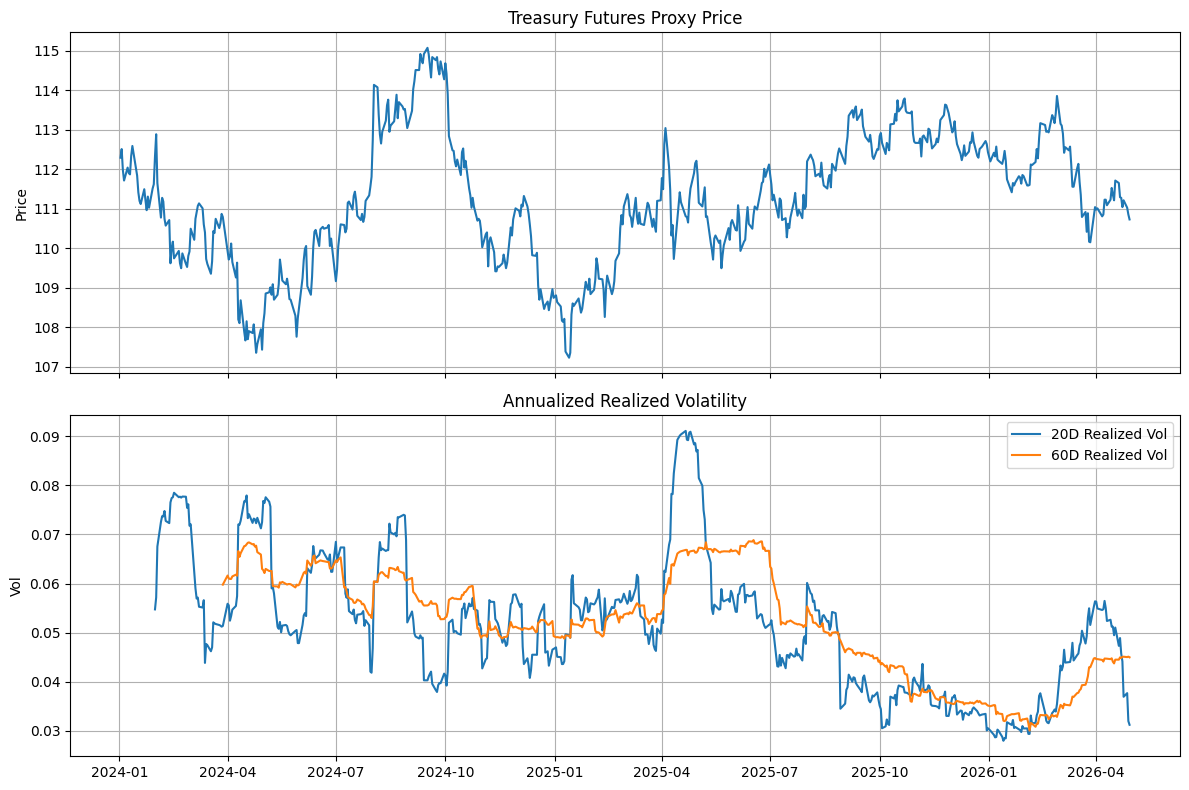

In [3]:
zn["ret"] = zn["close"].pct_change()
zn["rv_20"] = zn["ret"].rolling(20).std() * np.sqrt(252)
zn["rv_60"] = zn["ret"].rolling(60).std() * np.sqrt(252)

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0].plot(zn.index, zn["close"])
ax[0].set_title("Treasury Futures Proxy Price")
ax[0].set_ylabel("Price")
ax[0].grid(True)

ax[1].plot(zn.index, zn["rv_20"], label="20D Realized Vol")
ax[1].plot(zn.index, zn["rv_60"], label="60D Realized Vol")
ax[1].set_title("Annualized Realized Volatility")
ax[1].set_ylabel("Vol")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [4]:
F = float(zn["close"].iloc[-1])   # futures proxy level
K = round(F)                      # ATM-ish strike
T = 7 / 365                       # 1 week to expiry
r = 0.04                          # placeholder risk-free rate
sigma = float(zn["rv_20"].iloc[-1])  # use recent realized vol as a starting point

print("F:", F)
print("K:", K)
print("T:", T)
print("r:", r)
print("sigma:", sigma)

F: 110.734375
K: 111
T: 0.019178082191780823
r: 0.04
sigma: 0.031225788293398726


In [5]:
call_px = black76_call(F, K, T, r, sigma)
put_px = black76_put(F, K, T, r, sigma)
straddle_px = straddle_price(F, K, T, r, sigma)

print("Call price:", round(call_px, 4))
print("Put price:", round(put_px, 4))
print("Straddle price:", round(straddle_px, 4))

Call price: 0.087
Put price: 0.3524
Straddle price: 0.4394


In [6]:
upper_breakeven = K + straddle_px
lower_breakeven = K - straddle_px

print("Upper breakeven:", round(upper_breakeven, 4))
print("Lower breakeven:", round(lower_breakeven, 4))
print("Move needed:", round(straddle_px, 4))
print("Move needed as % of futures level:", round(straddle_px / F * 100, 3), "%")

Upper breakeven: 111.4394
Lower breakeven: 110.5606
Move needed: 0.4394
Move needed as % of futures level: 0.397 %


In [7]:
zn["abs_move"] = zn["close"].diff().abs()

print("Average daily absolute move (20D):", round(zn["abs_move"].rolling(20).mean().iloc[-1], 4))
print("Max daily absolute move (20D):", round(zn["abs_move"].rolling(20).max().iloc[-1], 4))
print("Average daily absolute move (60D):", round(zn["abs_move"].rolling(60).mean().iloc[-1], 4))

Average daily absolute move (20D): 0.1719
Max daily absolute move (20D): 0.5
Average daily absolute move (60D): 0.2419


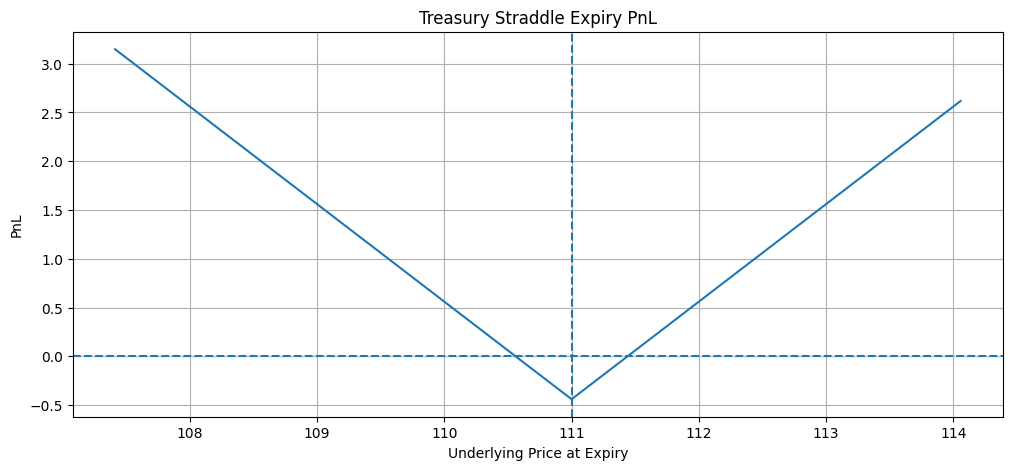

In [8]:
price_grid = np.linspace(F * 0.97, F * 1.03, 101)

pnl = []
for FT in price_grid:
    payoff = max(FT - K, 0) + max(K - FT, 0)
    pnl.append(payoff - straddle_px)

pnl_df = pd.DataFrame({"F_T": price_grid, "PnL": pnl})

plt.figure(figsize=(12, 5))
plt.plot(pnl_df["F_T"], pnl_df["PnL"])
plt.axhline(0, linestyle="--")
plt.axvline(K, linestyle="--")
plt.title("Treasury Straddle Expiry PnL")
plt.xlabel("Underlying Price at Expiry")
plt.ylabel("PnL")
plt.grid(True)
plt.show()

## Preliminary pre-trade conclusion

This notebook evaluates whether a short-dated Treasury straddle is attractive by comparing recent realized volatility and required breakeven moves. The trade becomes more attractive if the implied or assumed option premium implies a move that is small relative to recent realized event-sized moves. It becomes less attractive if the premium is too large relative to the likely move in the underlying.

In [9]:
avg_move_20 = zn["abs_move"].rolling(20).mean().iloc[-1]

if straddle_px < avg_move_20:
    print("Preliminary signal: straddle may be attractively priced relative to recent average daily moves.")
else:
    print("Preliminary signal: straddle may be expensive relative to recent average daily moves.")

Preliminary signal: straddle may be expensive relative to recent average daily moves.
